In [1]:
%matplotlib inline
import seaborn as sns
import numpy as np
import pandas as pd

## Fetching MINSTdataset from sklearn API
    *MINST = Modified National Institute of Standards and Technology

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
x, y = mnist["data"], mnist["target"]

In [4]:
x.shape

(70000, 784)

In [5]:
x.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
y.head()

0    5
1    0
2    4
3    1
4    9
Name: class, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

### Picking out one feature vector and converting it to an image

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [8]:
some_digit = x.to_numpy()[0]
some_digit_img = some_digit.reshape(28,28)

(-0.5, 27.5, 27.5, -0.5)

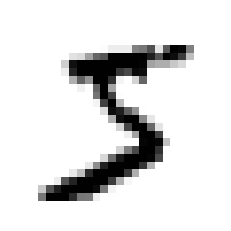

In [9]:

plt.imshow(some_digit_img,cmap='binary',interpolation="nearest")
plt.axis("off")

In [10]:
y[0], type(y[0]),type(y)

('5', str, pandas.core.series.Series)

In [11]:
y = mnist["target"].astype(np.uint8)

In [12]:
type(y[0])

numpy.uint8

### Before doing anything just split up the data

In [13]:
x_train,x_test,y_train,y_test = x[:60000],x[60000:],y[:60000],y[60000:]

### Training a binary classifier
Let’s simplify the problem for now and only try to identify one digit—for example,
the number 5. This “5-detector” will be an example of a binary classifier, capable of
distinguishing between just two classes, 5 and not-5

In [14]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)


## Using Stochastic Gradient Descent(SGD) as a classifier

In [15]:
from sklearn.linear_model import SGDClassifier

# using random_state to create reporducable results
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train,y_train_5)

SGDClassifier(random_state=42)

In [16]:
sgd_clf.predict([some_digit])

/home/suman/.pyenv/versions/mlENV/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

## Performance measure of the model

#### 1.Using custom Cross-validation

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

In [18]:
skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

In [19]:
x_train.shape, y_train_5.shape

((60000, 784), (60000,))

In [20]:
for train_index, test_index in skfolds.split(x_train,y_train_5):
    clone_clf = clone(sgd_clf)  # Cloning the raw classifier
    x_train_folds = x_train.values[train_index]
    y_train_folds = y_train_5[train_index]
    x_test_fold = x_train.values[test_index]
    y_test_fold = y_train_5[test_index]
    
    clone_clf.fit(x_train_folds,y_train_folds)
    y_pred = clone_clf.predict(x_test_fold)
    n_correct = sum (y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9669
0.91625
0.96785


### 2. Using sklearns CV function

In [21]:
from sklearn.model_selection import cross_val_score

In [22]:
cross_val_score(sgd_clf,x_train,y_train_5,cv=3,scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

Above 93% accuracy  on all cross-validation folds?
This looks amazing,but before you get too excited, let’s look at a very
dumb classifier that just classifies every single image in the “not-5” class:

In [23]:
from sklearn.base import BaseEstimator

In [24]:
# Our own custom classifier that does nothing
class Never5Classifier(BaseEstimator):
    def fit(self,x,y=None):
        pass
    def predict(self,x):
        return np.zeros((len(x),1),dtype=bool)

#### So we just created a custom sklearn Estimator by inheriting sklearns Baseestimator , we will now see what accuracy score does this dumb classifier gives

In [25]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf,x_train, y_train_5,cv=3,scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

That’s right, it has over 90% accuracy! This is simply because only about 10% of the
images are 5s, so if you always guess that an image is not a 5, you will be right about
90% of the time.

## Using Confusion Matrix for Performance measure 

In [26]:
from sklearn.model_selection import cross_val_predict

In [27]:
y_train_pred = cross_val_predict(sgd_clf,x_train,y_train_5,cv=3)

In [28]:
from sklearn.metrics import confusion_matrix

cf_mat = confusion_matrix(y_train_5,y_train_pred)
cf_mat

array([[53892,   687],
       [ 1891,  3530]])

A perfect classifier would have nonzero values only on its main diagonal

In [29]:
y_train_perfect_predictions = y_train_5
cf = confusion_matrix(y_train_5, y_train_perfect_predictions)
cf

array([[54579,     0],
       [    0,  5421]])

Its true that the confusion matrix gives alot of information but somtime you want a concise metric. One of those would be to check accuracy ot positive predictions . i.e
### Precision of classifier
precision =TP/(TP + FP)

tp = true positives

FP = false positives

precision is typically used
along with another metric named recall, also called sensitivity or true positive rate

recall =TP/(TP + FN)

FN = False Negatives

### Precision and recall provided by sklearn

In [30]:
from sklearn.metrics import precision_score, recall_score

In [31]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [32]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

## F-Score 
It is often a convinient way to combine precision and recall into a single metric , i.e known as F-scaore.

F1 score is the harmonic mean of precision and recall.

The classifier will only get a high F1 score if both recall and precision are
high.

In [33]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343846

## Precision / Recall Tradeoff

In [34]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

/home/suman/.pyenv/versions/mlENV/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [36]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [37]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

This confirms that raising the threshold decreases recall. The image actually repre‐
sents a 5, and the classifier detects it when the threshold is 0, but it misses it when the
threshold is increased to 8,000.

### Now how do you decide which threshold to use?

In [38]:
y_scores = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3, method="decision_function")

Now with these scores you can compute precision and recall for all possible thresh‐
olds using the precision_recall_curve() function:

In [40]:
from sklearn.metrics import precision_recall_curve

precisions, recalls , thresholds = precision_recall_curve(y_train_5, y_scores)

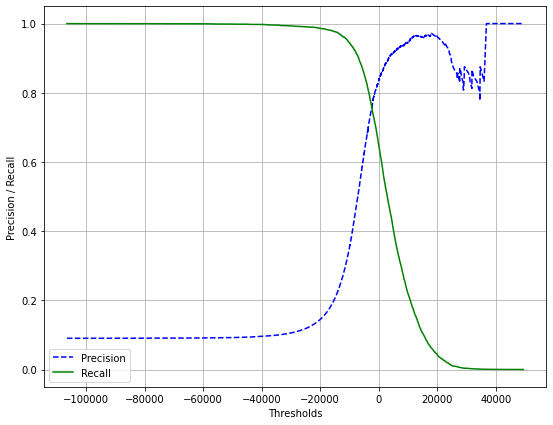

In [45]:
def plot_precision_recall_vs_threshold(precisions, recalls,thresholds):
    plt.figure(figsize=(9,7))
    plt.plot(thresholds,precisions[:-1],"b--",label="Precision")
    plt.plot(thresholds,recalls[:-1],"g-",label="Recall")
    
    plt.legend()
    plt.xlabel("Thresholds")
    plt.ylabel("Precision / Recall")
    plt.grid()

plot_precision_recall_vs_threshold(precisions,recalls,thresholds)

## ROC(receiver operating characterstic) Curve
=> It basically gives a plot between true positive rate(recall) vs false positive rate
=> To plot the ROC curve, you first need to compute the TPR and FPR for various thres‐
hold values, using the roc_curve() function:

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


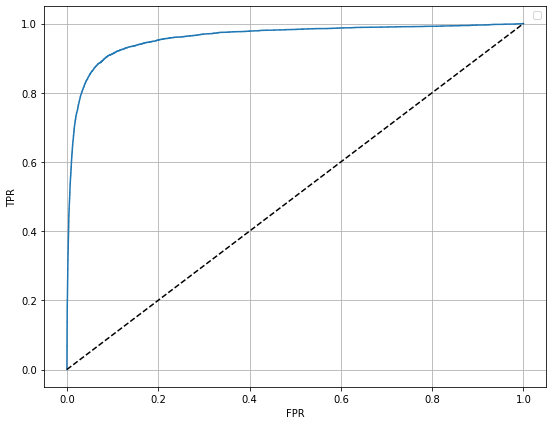

In [51]:
def plot_roc_curve(fpr,tpr,label=None):
    plt.figure(figsize=(9,7))
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1],'k--')
    
    plt.legend()
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.grid()

plot_roc_curve(fpr,tpr)